## Полносвязные нейронные сети (FCNN). Решение задачи регрессии 

In [7]:
import pandas as pd
import optuna
import joblib
import tensorflow as tf
import warnings
import numpy as np

from sklearn.model_selection import KFold, cross_val_score
from matplotlib import pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import cross_val_predict, train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest
from sklearn.neural_network import MLPRegressor

/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Чтение данных

In [4]:
data = pd.read_csv("../data/diamonds_filtered.csv")
data.head(10)

,carat,cut,color,clarity,depth,table,price,radius
0,0.29,4,2,4,62.4,58,334,2.100
1,0.31,2,1,2,63.3,58,335,2.170
2,0.30,2,1,3,64.0,55,339,2.125
3,0.31,5,1,2,62.2,54,344,2.175
4,0.32,4,6,1,60.9,58,345,2.190
5,0.30,5,2,2,62.0,54,348,2.155
6,0.30,2,1,3,63.4,54,351,2.115
7,0.30,2,1,3,63.8,56,351,2.115
8,0.30,3,1,3,62.7,59,351,2.105
9,0.30,2,2,2,63.3,56,351,2.130


### Выделение целевого признака и предиктора

In [5]:
y = data['price']
x = data.drop('price', axis=1)

### Оптимизация признакового пространства

In [8]:
skb = SelectKBest(k=4)
x_skb = skb.fit_transform(x, y)

### MLPRegressor

In [5]:
def print_mlp_architecture(pipeline):
    mlp = pipeline.named_steps['mlp']
    print(f"Входных признаков: {mlp.n_features_in_}")
    print(f"Скрытые слои: {mlp.hidden_layer_sizes}")
    print(f"Количество слоев (всего): {mlp.n_layers_}")
    print(f"Выходной слой: {mlp.n_outputs_}")
    print(f"Функция активации: {mlp.activation}")
    print(f"Оптимизатор: {mlp.solver}")

def plot_learning_curves(pipeline, title="Обучение модели"):
    mlp = pipeline.named_steps['mlp']
    
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.plot(mlp.loss_curve_, label='Training Loss', color='blue', lw=2)
    ax1.set_xlabel('Эпохи (итерации)')
    ax1.set_ylabel('Loss (MSE)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.6)

    if hasattr(mlp, 'validation_scores_'):
        ax2 = ax1.twinx()
        ax2.plot(mlp.validation_scores_, label='Validation $R^2$', color='red', lw=2)
        ax2.set_ylabel('Score ($R^2$)', color='red')
        ax2.tick_params(axis='y', labelcolor='red')
    
    plt.title(title)
    fig.tight_layout()
    plt.show()

R^2 = 0.9724


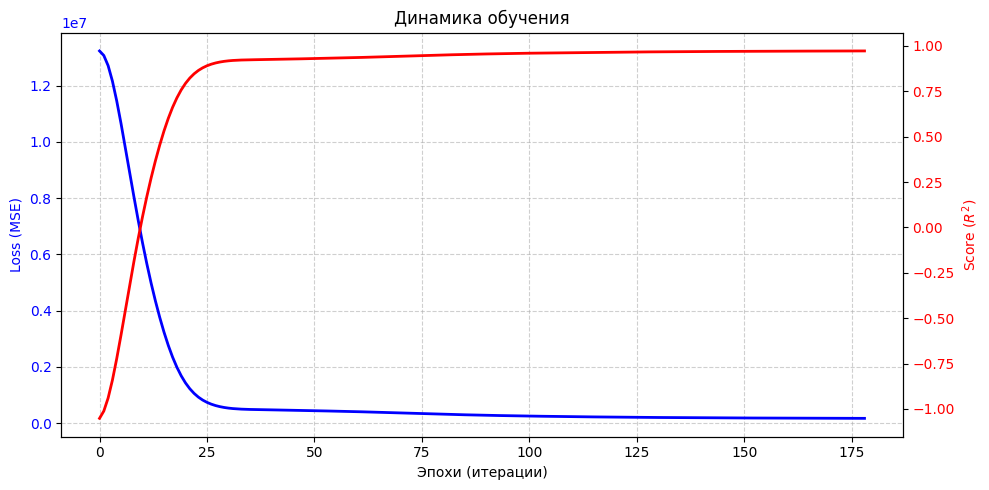

In [6]:
base_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(early_stopping=True, max_iter=1000))
])

base_kf = KFold(n_splits=5, shuffle=True, random_state=81)

y_pred_base = cross_val_predict(base_pipeline, x_skb, y, cv=base_kf, n_jobs=-1)
r2_base = r2_score(y, y_pred_base)
print(f"R^2 = {round(r2_base, 4)}")

base_pipeline.fit(x_skb, y)

plot_learning_curves(base_pipeline, title="Динамика обучения")

In [7]:
print_mlp_architecture(pipeline=base_pipeline)

Входных признаков: 4
Скрытые слои: (100,)
Количество слоев (всего): 3
Выходной слой: 1
Функция активации: relu
Оптимизатор: adam


In [8]:
joblib.dump(base_pipeline, '../models/base_mlp_optuna.pkl')

['../models/base_mlp_optuna.pkl']

### MLPRegressor с Optuna

In [9]:
def objective(trial):
    params = {
        'hidden_layer_sizes': trial.suggest_categorical(
            'hidden_layer_sizes', 
            [(50,), (100,), (100, 50), (150, 100)] 
        ),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
        'alpha': trial.suggest_float('alpha', 1e-4, 1e-2, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-3, 1e-2, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [128, 256, 'auto']), 
    }
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(
            **params,
            solver='adam', 
            random_state=81,
            early_stopping=True,
            max_iter=400,          
            n_iter_no_change=10,   
            validation_fraction=0.1
        ))
    ])

    cv = KFold(n_splits=3, shuffle=True, random_state=81) 
    
    scores = cross_val_score(
        pipeline, 
        x_skb, 
        y, 
        cv=cv, 
        scoring='r2',
        n_jobs=-1 
    )
    
    return scores.mean()

In [10]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

[I 2026-05-05 16:03:36,916] A new study created in memory with name: no-name-bb50d329-ca8a-478d-b9c6-7049585772bf


  0%|          | 0/50 [00:00<?, ?it/s]

/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50,) which is of type tuple.
  optuna_warn(message)
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  optuna_warn(message)
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 50) which is of type tuple.
  optuna_warn(message)
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/p

[I 2026-05-05 16:04:03,439] Trial 0 finished with value: 0.9056554690269332 and parameters: {'hidden_layer_sizes': (100, 50), 'activation': 'tanh', 'alpha': 0.0018890420555323798, 'learning_rate_init': 0.0022856132025472807, 'batch_size': 128}. Best is trial 0 with value: 0.9056554690269332.
[I 2026-05-05 16:04:06,058] Trial 1 finished with value: 0.9747633861318308 and parameters: {'hidden_layer_sizes': (50,), 'activation': 'relu', 'alpha': 0.00032333690110227843, 'learning_rate_init': 0.004229032537207133, 'batch_size': 256}. Best is trial 1 with value: 0.9747633861318308.


/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


...

[I 2026-05-05 16:13:01,884] Trial 32 finished with value: 0.9757256048737554 and parameters: {'hidden_layer_sizes': (150, 100), 'activation': 'tanh', 'alpha': 0.0002226025750825273, 'learning_rate_init': 0.0036856393127704086, 'batch_size': 256}. Best is trial 7 with value: 0.9801782846114885.


/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


[I 2026-05-05 16:13:45,483] Trial 33 finished with value: 0.9794009372377488 and parameters: {'hidden_layer_sizes': (150, 100), 'activation': 'tanh', 'alpha': 0.0007157044206513067, 'learning_rate_init': 0.004355382778550518, 'batch_size': 256}. Best is trial 7 with value: 0.9801782846114885.
[I 2026-05-05 16:13:51,275] Trial 34 finished with value: 0.9791008150434007 and parameters: {'hidden_layer_sizes': (150, 100), 'activation': 'relu', 'alpha': 0.001136863141658595, 'learning_rate_init': 0.005698434291514123, 'batch_size': 256}. Best is trial 7 with value: 0.9801782846114885.


/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


[I 2026-05-05 16:13:57,387] Trial 35 finished with value: 0.9769070745239326 and parameters: {'hidden_layer_sizes': (50,), 'activation': 'tanh', 'alpha': 0.0004001417967938641, 'learning_rate_init': 0.007952094170807772, 'batch_size': 256}. Best is trial 7 with value: 0.9801782846114885.
[I 2026-05-05 16:14:02,132] Trial 36 finished with value: 0.9801442356579617 and parameters: {'hidden_layer_sizes': (100,), 'activation': 'tanh', 'alpha': 0.006345026039669714, 'learning_rate_init': 0.008988308518310905, 'batch_size': 128}. Best is trial 7 with value: 0.9801782846114885.
[I 2026-05-05 16:14:04,153] Trial 37 finished with value: 0.9758770561010767 and parameters: {'hidden_layer_sizes': (100,), 'activation': 'relu', 'alpha': 0.006848563915297683, 'learning_rate_init': 0.009100940876807856, 'batch_size': 128}. Best is trial 7 with value: 0.9801782846114885.
[I 2026-05-05 16:14:10,282] Trial 38 finished with value: 0.9799679618637928 and parameters: {'hidden_layer_sizes': (100,), 'activati

In [11]:
joblib.dump(study, '../models/study_mlp_optuna.pkl')

['../models/study_mlp_optuna.pkl']

R^2 = 0.9803


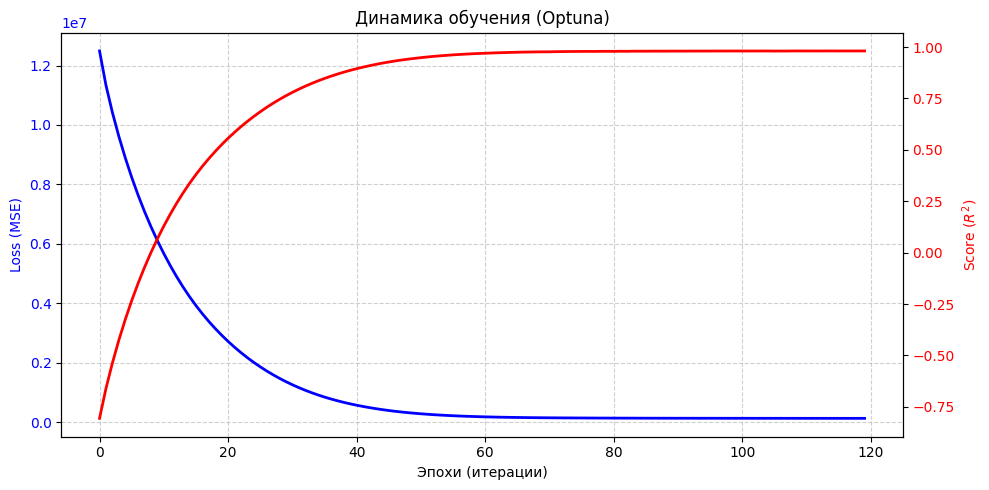

Входных признаков: 4
Скрытые слои: (100,)
Количество слоев (всего): 3
Выходной слой: 1
Функция активации: tanh
Оптимизатор: adam


In [12]:
optuna_tf_params = study.best_params
optuna_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        **optuna_tf_params,
        random_state=81,
        early_stopping=True,
        max_iter=400,
        n_iter_no_change=10,
        validation_fraction=0.1
    ))
])

base_kf = KFold(n_splits=5, shuffle=True, random_state=81)

y_pred_optuna = cross_val_predict(optuna_pipeline, x_skb, y, cv=base_kf, n_jobs=-1)
r2_optuna = r2_score(y, y_pred_optuna)
print(f"R^2 = {round(r2_optuna, 4)}")

optuna_pipeline.fit(x_skb, y)
plot_learning_curves(optuna_pipeline, title="Динамика обучения (Optuna)")
print_mlp_architecture(optuna_pipeline)

fig = optuna.visualization.plot_param_importances(study)
fig.show()

fig2 = optuna.visualization.plot_optimization_history(study)
fig2.show()

In [13]:
joblib.dump(optuna_pipeline, 'pipeline_mlp_optuna.pkl')

['pipeline_mlp_optuna.pkl']

In [14]:
results = []

results.append({"Algorithm" : "MLPRegressor Base", "R^2": round(r2_base, 4)})
results.append({"Algorithm" : "MLPRegressor Optuna", "R^2": round(r2_optuna, 4)})

In [15]:
res = pd.DataFrame(results)
res

,Algorithm,R^2
0,MLPRegressor Base,0.9724
1,MLPRegressor Optuna,0.9803


### TensorFlow

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x_skb, y, test_size=0.15)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [17]:
def r_squared(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    total_variance = tf.math.reduce_variance(y_true)
    unexplained_variance = tf.math.reduce_variance(y_true - y_pred)
    
    return 1 - unexplained_variance / (total_variance + tf.keras.backend.epsilon())

def plot_history(history, title):
    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.plot(history.history['loss'], color='blue', label='Loss (MSE)')
    ax1.set_xlabel('Эпохи (итерации)')
    ax1.set_ylabel('Loss (MSE)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.6)

    ax2 = ax1.twinx()
    ax2.plot(history.history['r_squared'], color='red', label='Score ($R^2$)')
    ax2.set_ylabel('Score ($R^2$)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    plt.title(title)
    fig.tight_layout()
    plt.show()

In [19]:
normalizer = tf.keras.layers.Normalization()
normalizer.adapt(x_skb)

base_tensorflow = tf.keras.Sequential(
    [
        normalizer,
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="linear"),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(1, activation="linear"),
    ]
)

In [20]:
base_tensorflow.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='mse',
    metrics=[r_squared]
)

history = base_tensorflow.fit(x_train, y_train, epochs=50)
y_pred_base_tf = base_tensorflow.predict(x_test)

r2_base_tf = r2_score(y_test, y_pred_base_tf)
print(f"R^2 = {r2_base_tf}")

Epoch 1/50
1288/1288 [==============================] - 1s 286us/step - loss: 2781087.2500 - r_squared: 0.8158
Epoch 2/50
1288/1288 [==============================] - 0s 279us/step - loss: 948989.2500 - r_squared: 0.9260
Epoch 3/50
1288/1288 [==============================] - 0s 300us/step - loss: 910061.6250 - r_squared: 0.9290
Epoch 4/50
1288/1288 [==============================] - 0s 297us/step - loss: 887290.1875 - r_squared: 0.9314
Epoch 5/50
1288/1288 [==============================] - 0s 297us/step - loss: 823747.8750 - r_squared: 0.9357
Epoch 6/50
1288/1288 [==============================] - 0s 280us/step - loss: 772264.1250 - r_squared: 0.9401
Epoch 7/50
1288/1288 [==============================] - 0s 281us/step - loss: 723384.6250 - r_squared: 0.9436
Epoch 8/50
1288/1288 [==============================] - 0s 280us/step - loss: 707454.5625 - r_squared: 0.9452
Epoch 9/50
1288/1288 [==============================] - 0s 283us/step - loss: 676318.3750 - r_squared: 0.9475
Epoch 10/

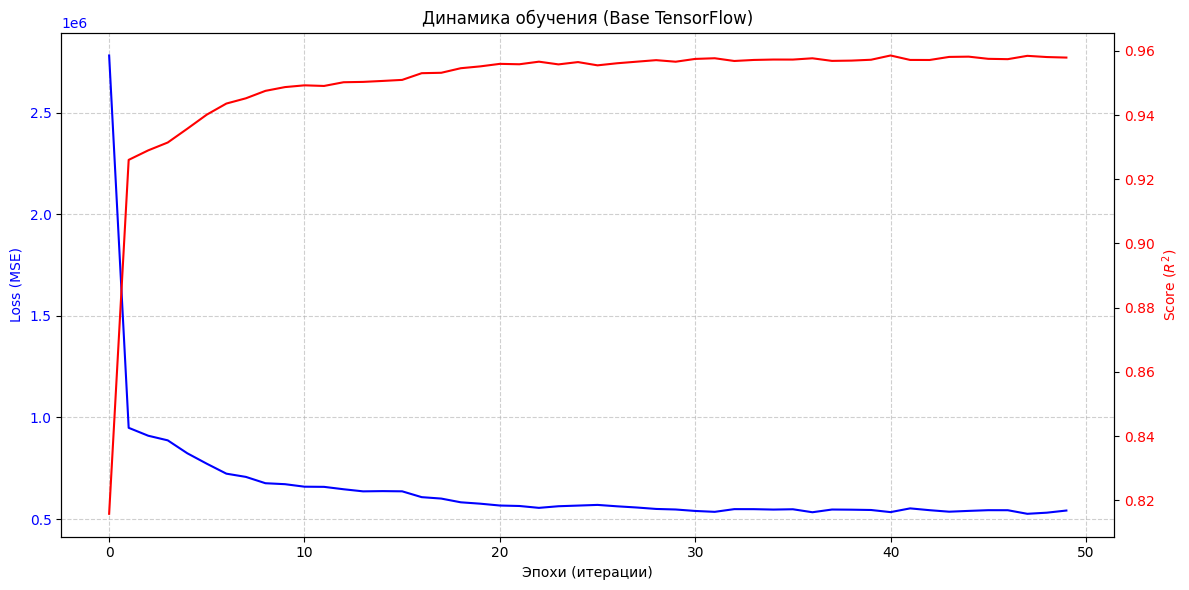

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization_1 (Normaliza  (None, 4)                 9         
 tion)                                                           
                                                                 
 dense_1 (Dense)             (None, 64)                320       
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_3 (Dense)             (None, 16)                528       
                                                                 
 dropout_1 (Dropout)         (None, 16)                0         
                                                        

In [21]:
plot_history(history=history, title='Динамика обучения (Base TensorFlow)')
base_tensorflow.summary()

In [22]:
base_tensorflow.save('../models/base_tf.keras')

In [23]:
results.append({"Algorithm" : "TensorFlow Base", "R^2": round(r2_base_tf, 4)})

res = pd.DataFrame(results)
res

,Algorithm,R^2
0,MLPRegressor Base,0.9724
1,MLPRegressor Optuna,0.9803
2,TensorFlow Base,0.9565


### TensorFlow с Optuna

In [24]:
from tensorflow import keras
    

In [25]:
input_shape = x_train.shape[1]
num_classes = len(np.unique(np.concatenate([y_train, y_test])))

def objective(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop'])
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 0.1, log=True)
    batch_size = trial.suggest_int('batch_size', 16, 128, step=32)

    if optimizer_name == 'adam':
        optimizer = keras.optimizers.legacy.Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        optimizer = keras.optimizers.legacy.SGD(learning_rate=learning_rate)
    else:  
        optimizer = keras.optimizers.legacy.RMSprop(learning_rate=learning_rate)
    
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(input_shape,)))
    
    for i in range(n_layers):
        n_units = trial.suggest_int(f'n_units_l{i}', 16, 256, step=32)
        model.add(keras.layers.Dense(n_units, activation=activation))
        dropout = trial.suggest_float(f'dropout_l{i}', 0.0, 0.5)
        model.add(keras.layers.Dropout(dropout))
    
    model.add(keras.layers.Dense(1, activation='linear'))
    
    model.compile(optimizer=optimizer,
                  loss='mse',
                  metrics=[r_squared])
    
    history = model.fit(
        x_train, y_train,
        batch_size=batch_size,
        epochs=20,
        verbose=0
    )
    r2_score = max(history.history['r_squared'])

    return float(r2_score)

In [26]:
study_tf = optuna.create_study(direction='maximize')
study_tf.optimize(objective, n_trials=50, show_progress_bar=True)

optuna_tf_params = study_tf.best_params
print(f"R^2 = {round(study_tf.best_value, 4)}")


[I 2026-05-05 16:17:21,505] A new study created in memory with name: no-name-eb12d313-b646-4c57-b31a-4a3aaceae058


  0%|          | 0/50 [00:00<?, ?it/s]

/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/optuna/distributions.py:684: UserWarning: The distribution is specified by [16, 128] and step=32, but the range is not divisible by `step`. It will be replaced with [16, 112].
  optuna_warn(
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/optuna/distributions.py:684: UserWarning: The distribution is specified by [16, 256] and step=32, but the range is not divisible by `step`. It will be replaced with [16, 240].
  optuna_warn(


[W 2026-05-05 16:17:34,817] Trial 0 failed with parameters: {'n_layers': 3, 'activation': 'relu', 'optimizer': 'sgd', 'learning_rate': 0.0008782268458962609, 'batch_size': 16, 'n_units_l0': 208, 'dropout_l0': 0.3531072096962082, 'n_units_l1': 112, 'dropout_l1': 0.3818422453305052, 'n_units_l2': 48, 'dropout_l2': 0.3560438850378375} because of the following error: The value nan is not acceptable.
[W 2026-05-05 16:17:34,817] Trial 0 failed with value nan.
[I 2026-05-05 16:17:38,083] Trial 1 finished with value: 0.9326335191726685 and parameters: {'n_layers': 2, 'activation': 'relu', 'optimizer': 'rmsprop', 'learning_rate': 0.013250266100608183, 'batch_size': 112, 'n_units_l0': 144, 'dropout_l0': 0.4345891523218551, 'n_units_l1': 144, 'dropout_l1': 0.4876259920606842}. Best is trial 1 with value: 0.9326335191726685.
[W 2026-05-05 16:17:40,154] Trial 2 failed with parameters: {'n_layers': 1, 'activation': 'relu', 'optimizer': 'sgd', 'learning_rate': 0.056742776855232185, 'batch_size': 80, 

In [27]:
optuna_tf = keras.Sequential()
optuna_tf.add(keras.layers.Input(shape=(input_shape,)))

for i in range(optuna_tf_params['n_layers']):
    n_units = optuna_tf_params[f'n_units_l{i}']
    optuna_tf.add(keras.layers.Dense(n_units, activation=optuna_tf_params['activation']))
    optuna_tf.add(keras.layers.Dropout(optuna_tf_params[f'dropout_l{i}']))

optuna_tf.add(keras.layers.Dense(1, activation='linear'))

optimizer_name = optuna_tf_params['optimizer']
lr = optuna_tf_params['learning_rate']
if optimizer_name == 'adam':
    optimizer = keras.optimizers.legacy.Adam(learning_rate=lr)
elif optimizer_name == 'sgd':
    optimizer = keras.optimizers.legacy.SGD(learning_rate=lr)
else:
    optimizer = keras.optimizers.legacy.RMSprop(learning_rate=lr)

optuna_tf.compile(optimizer=optimizer, loss='mse', metrics=[r_squared])

In [28]:
optuna_tf.summary()

Model: "sequential_51"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_128 (Dense)           (None, 208)               1040      
                                                                 
 dropout_75 (Dropout)        (None, 208)               0         
                                                                 
 dense_129 (Dense)           (None, 1)                 209       
                                                                 
Total params: 1249 (4.88 KB)
Trainable params: 1249 (4.88 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [29]:
optuna_tf.save('../models/optuna_tf.keras')

Epoch 1/50
2576/2576 [==============================] - 1s 270us/step - loss: 2939369.7500 - r_squared: 0.8520
Epoch 2/50
2576/2576 [==============================] - 1s 277us/step - loss: 593554.8125 - r_squared: 0.9476
Epoch 3/50
2576/2576 [==============================] - 1s 262us/step - loss: 481932.4062 - r_squared: 0.9578
Epoch 4/50
2576/2576 [==============================] - 1s 257us/step - loss: 431651.2500 - r_squared: 0.9618
Epoch 5/50
2576/2576 [==============================] - 1s 260us/step - loss: 402540.1562 - r_squared: 0.9649
Epoch 6/50
2576/2576 [==============================] - 1s 261us/step - loss: 390015.3125 - r_squared: 0.9650
Epoch 7/50
2576/2576 [==============================] - 1s 262us/step - loss: 384248.7500 - r_squared: 0.9656
Epoch 8/50
2576/2576 [==============================] - 1s 255us/step - loss: 381160.5938 - r_squared: 0.9666
Epoch 9/50
2576/2576 [==============================] - 1s 255us/step - loss: 372410.6562 - r_squared: 0.9671
Epoch 10/

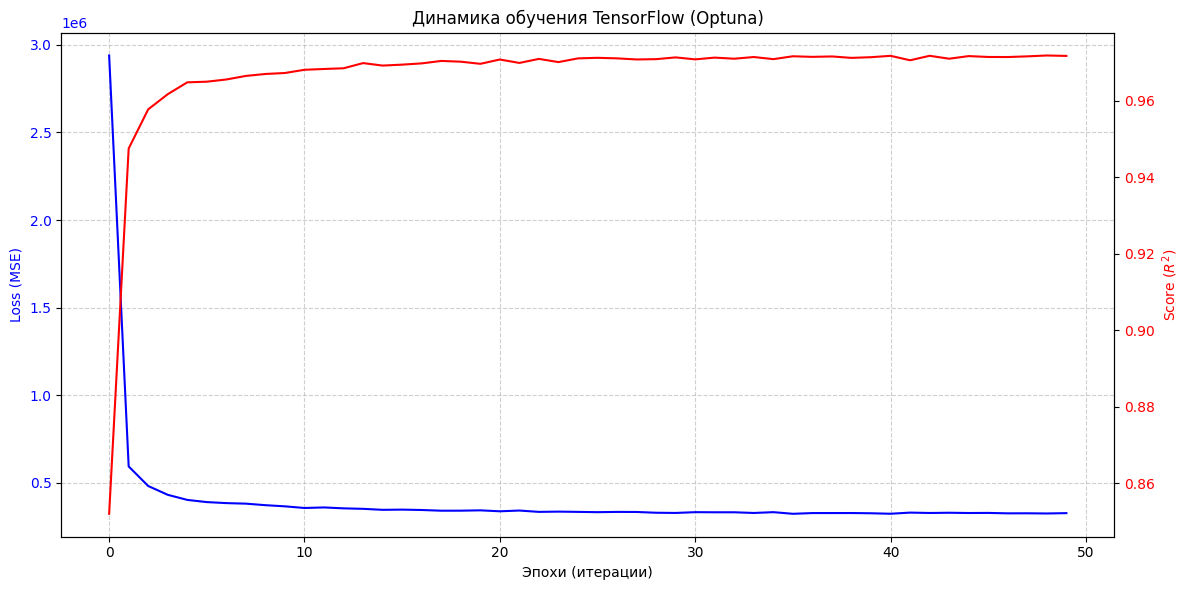

In [30]:
history_optuna_tf = optuna_tf.fit(
    x_train, y_train,
    batch_size=optuna_tf_params['batch_size'],
    epochs=50
)

plot_history(history_optuna_tf, f'Динамика обучения TensorFlow (Optuna)')


fig = optuna.visualization.plot_param_importances(study_tf)
fig.show()

fig2 = optuna.visualization.plot_optimization_history(study_tf)
fig2.show()

In [31]:
results.append({"Algorithm" : "TensorFlow Optuna", "R^2": round(r2_base_tf, 4)})

res = pd.DataFrame(results)
res

,Algorithm,R^2
0,MLPRegressor Base,0.9724
1,MLPRegressor Optuna,0.9803
2,TensorFlow Base,0.9565
3,TensorFlow Optuna,0.9565


### Вывод

Лучше всего справился многослойный перцептрон с оптимизацией гиперпараметров при помощи `optuna`.

### Инференс модели MLPRegressor Optuna

In [ ]:
model = joblib.load('../models/mlp_optuna.pkl')

x_diamond = pd.DataFrame(
    columns=['carat', 'color', 'clarity', 'radius'],
    data=[[0.29,2,4,2.1]]
)

y_pred = model.predict(x_diamond)

print(f"Стоимость алмаза = {round(y_pred[0], 4)}")


Стоимость алмаза = 447.0374


/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
